#Temporal_Sequences

In [1]:
# Cell 1 — Mount Drive + imports
from google.colab import drive
drive.mount('/content/drive')

import os, cv2, random
import numpy as np
import matplotlib.pyplot as plt

BASE         = "/content/drive/MyDrive/EyeMotionID"
MRL_PATH     = os.path.join(BASE, "data/raw/MRL_Eye/data")
MPI_PATH     = os.path.join(BASE, "data/raw/MPIIGAZE/MPIIGaze/Data/Original")
OPENEDS_PATH = os.path.join(BASE, "data/raw/openeds/openEDS/openEDS")
SEQ_PATH     = os.path.join(BASE, "data/sequences")
os.makedirs(SEQ_PATH, exist_ok=True)

print("✓ Drive mounted")
print("MRL exists    :", os.path.exists(MRL_PATH))
print("MPII exists   :", os.path.exists(MPI_PATH))
print("OpenEDS exists:", os.path.exists(OPENEDS_PATH))

Mounted at /content/drive
✓ Drive mounted
MRL exists    : True
MPII exists   : True
OpenEDS exists: True


##What are temporal sequences?

######The concept — groups consecutive frames into sequences for LSTM input.

In [2]:
# Temporal sequences explained
# Instead of training on single images, we group consecutive frames
# into sequences of N frames → this captures behavioral patterns over time
#
# Example for EyeDentify (subject 1, session 1):
# frame_01.png, frame_02.png ... frame_90.png
#
# With SEQUENCE_LENGTH = 10:
# Sequence 1 → [frame_01, frame_02, ..., frame_10]
# Sequence 2 → [frame_02, frame_03, ..., frame_11]  ← sliding window
# Sequence 3 → [frame_03, frame_04, ..., frame_12]
# ...
#
# Each sequence = one training sample for CNN + LSTM
# Shape: (10, 224, 224, 3) → 10 frames, each 224x224 RGB

SEQUENCE_LENGTH = 10   # number of frames per sequence
STRIDE          = 5    # step between sequences (overlap)
IMG_SIZE        = (64, 64)  # resize for faster processing

print("=== Temporal Sequence Parameters ===")
print(f"Sequence length : {SEQUENCE_LENGTH} frames")
print(f"Stride          : {STRIDE} frames")
print(f"Image size      : {IMG_SIZE[0]}x{IMG_SIZE[1]} px")
print()
print("Example: 90 frames → how many sequences?")
n_frames = 90
n_seqs   = (n_frames - SEQUENCE_LENGTH) // STRIDE + 1
print(f"  ({n_frames} - {SEQUENCE_LENGTH}) // {STRIDE} + 1 = {n_seqs} sequences")

=== Temporal Sequence Parameters ===
Sequence length : 10 frames
Stride          : 5 frames
Image size      : 64x64 px

Example: 90 frames → how many sequences?
  (90 - 10) // 5 + 1 = 17 sequences


###Create sequences from MRL Eye Dataset

In [3]:
import os, cv2
import numpy as np

def create_sequences_from_folder(folder_path, label, seq_len=10, stride=5, img_size=(64,64)):
    """
    Creates temporal sequences from a folder of images.
    Returns: list of (sequence_array, label) tuples
    """
    ext = {".jpg", ".jpeg", ".png", ".bmp"}
    images = sorted([f for f in os.listdir(folder_path)
                     if os.path.splitext(f)[1].lower() in ext])

    if len(images) < seq_len:
        return []

    sequences = []
    for start in range(0, len(images) - seq_len + 1, stride):
        seq_frames = []
        for i in range(start, start + seq_len):
            img = cv2.imread(os.path.join(folder_path, images[i]))
            if img is None: continue
            img = cv2.resize(img, img_size)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            seq_frames.append(img)
        if len(seq_frames) == seq_len:
            sequences.append((np.array(seq_frames), label))
    return sequences

# create sequences from MRL train split
mrl_sequences = []
for cls, label in [("awake", 1), ("sleepy", 0)]:
    cls_path = os.path.join(MRL_PATH, "train", cls)
    seqs     = create_sequences_from_folder(cls_path, label)
    mrl_sequences.extend(seqs)
    print(f"  MRL {cls:8s} → {len(seqs):,} sequences")

print(f"\nTotal MRL sequences : {len(mrl_sequences):,}")
print(f"Sequence shape      : {mrl_sequences[0][0].shape}")  # (10, 64, 64, 3)

  MRL awake    → 5,153 sequences
  MRL sleepy   → 5,032 sequences

Total MRL sequences : 10,185
Sequence shape      : (10, 64, 64, 3)


###Create sequences from MPIIGaze

In [4]:
mpi_sequences = []
participants  = sorted(os.listdir(MPI_PATH))
ext = {".jpg", ".jpeg", ".png"}

for p_idx, p in enumerate(participants):
    p_path = os.path.join(MPI_PATH, p)
    p_seqs = 0
    for day in sorted(os.listdir(p_path)):
        day_path = os.path.join(p_path, day)
        if not os.path.isdir(day_path): continue
        seqs = create_sequences_from_folder(day_path, p_idx)
        mpi_sequences.extend(seqs)
        p_seqs += len(seqs)
    print(f"  {p} (label={p_idx:2d}) → {p_seqs:,} sequences")

print(f"\nTotal MPIIGaze sequences : {len(mpi_sequences):,}")
print(f"Sequence shape           : {mpi_sequences[0][0].shape}")

  p00 (label= 0) → 5,947 sequences
  p01 (label= 1) → 4,737 sequences
  p02 (label= 2) → 5,559 sequences
  p03 (label= 3) → 6,926 sequences
  p04 (label= 4) → 3,332 sequences
  p05 (label= 5) → 3,271 sequences
  p06 (label= 6) → 3,611 sequences
  p07 (label= 7) → 3,033 sequences
  p08 (label= 8) → 2,077 sequences
  p09 (label= 9) → 1,574 sequences
  p10 (label=10) → 542 sequences
  p11 (label=11) → 576 sequences
  p12 (label=12) → 314 sequences
  p13 (label=13) → 284 sequences
  p14 (label=14) → 293 sequences

Total MPIIGaze sequences : 42,076
Sequence shape           : (10, 64, 64, 3)


###Create sequences from OpenEDS

In [5]:
openeds_sequences = []
subjects = sorted([d for d in os.listdir(OPENEDS_PATH)
                   if os.path.isdir(os.path.join(OPENEDS_PATH, d))])

for s_idx, s in enumerate(subjects):
    s_path = os.path.join(OPENEDS_PATH, s)
    seqs   = create_sequences_from_folder(s_path, s_idx)
    openeds_sequences.extend(seqs)
    print(f"  {s} (label={s_idx:2d}) → {len(seqs):,} sequences")

print(f"\nTotal OpenEDS sequences : {len(openeds_sequences):,}")
if openeds_sequences:
    print(f"Sequence shape          : {openeds_sequences[0][0].shape}")

  S_0 (label= 0) → 30 sequences
  S_1 (label= 1) → 29 sequences
  S_10 (label= 2) → 31 sequences
  S_101 (label= 3) → 27 sequences
  S_102 (label= 4) → 27 sequences
  S_103 (label= 5) → 27 sequences
  S_104 (label= 6) → 27 sequences
  S_105 (label= 7) → 29 sequences
  S_106 (label= 8) → 27 sequences
  S_107 (label= 9) → 27 sequences
  S_108 (label=10) → 27 sequences
  S_109 (label=11) → 27 sequences
  S_11 (label=12) → 27 sequences
  S_110 (label=13) → 27 sequences
  S_111 (label=14) → 27 sequences
  S_112 (label=15) → 27 sequences
  S_113 (label=16) → 27 sequences
  S_114 (label=17) → 27 sequences
  S_115 (label=18) → 27 sequences
  S_116 (label=19) → 27 sequences
  S_117 (label=20) → 30 sequences
  S_118 (label=21) → 30 sequences
  S_119 (label=22) → 27 sequences
  S_12 (label=23) → 27 sequences
  S_122 (label=24) → 27 sequences
  S_123 (label=25) → 27 sequences
  S_124 (label=26) → 23 sequences

Total OpenEDS sequences : 742
Sequence shape          : (10, 64, 64, 3)


###Visualize one temporal sequence

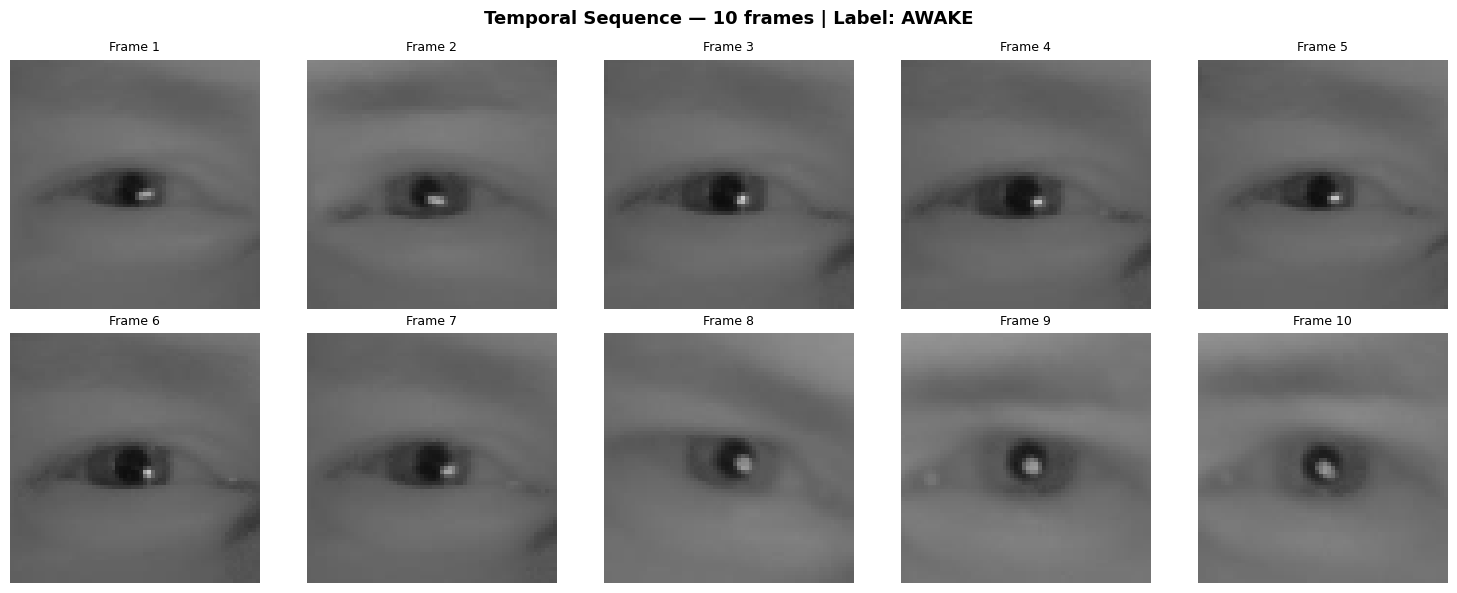

✓ Sequence shape : (10, 64, 64, 3)
✓ Label          : 1 (AWAKE)
✓ Saved → results/plots/temporal_sequence_sample.png


In [6]:
# pick a random MRL sequence and visualize all 10 frames
seq_array, seq_label = random.choice(mrl_sequences)
label_name = "AWAKE" if seq_label == 1 else "SLEEPY"

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle(f"Temporal Sequence — {SEQUENCE_LENGTH} frames | Label: {label_name}",
             fontsize=13, fontweight='bold')

for i, ax in enumerate(axes.flat):
    ax.imshow(seq_array[i])
    ax.set_title(f"Frame {i+1}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
PLOTS = os.path.join(BASE, "results/plots")
plt.savefig(f"{PLOTS}/temporal_sequence_sample.png", dpi=100)
plt.show()
print(f"✓ Sequence shape : {seq_array.shape}")
print(f"✓ Label          : {seq_label} ({label_name})")
print("✓ Saved → results/plots/temporal_sequence_sample.png")

###Bar chart comparing number of sequences generated from each dataset.

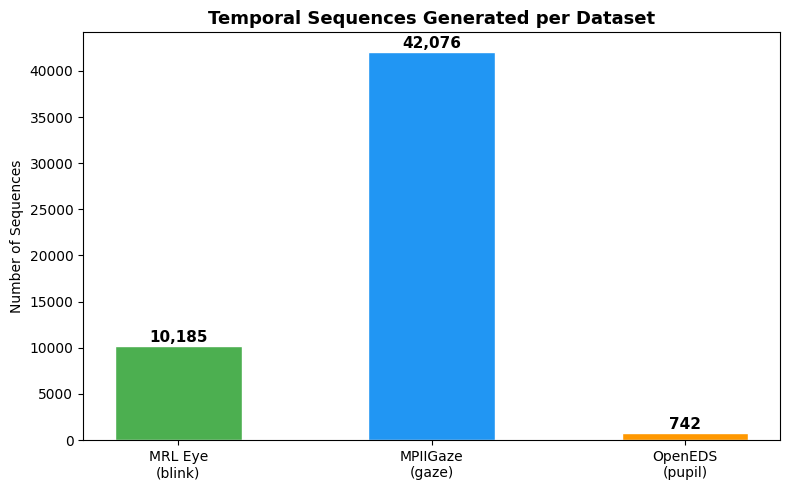

✓ Saved → results/plots/sequence_counts.png


In [7]:
datasets = ["MRL Eye\n(blink)", "MPIIGaze\n(gaze)", "OpenEDS\n(pupil)"]
counts   = [len(mrl_sequences), len(mpi_sequences), len(openeds_sequences)]
colors   = ["#4CAF50", "#2196F3", "#FF9800"]

plt.figure(figsize=(8, 5))
bars = plt.bar(datasets, counts, color=colors, edgecolor='white', width=0.5)
plt.title("Temporal Sequences Generated per Dataset",
          fontsize=13, fontweight='bold')
plt.ylabel("Number of Sequences")
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + max(counts)*0.01,
             f"{count:,}", ha="center", fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{PLOTS}/sequence_counts.png", dpi=100)
plt.show()
print("✓ Saved → results/plots/sequence_counts.png")

###Save sequence metadata to CSV

In [8]:
import pandas as pd

records = []

# MRL sequences
for i, (seq, label) in enumerate(mrl_sequences[:5]):
    records.append({
        "dataset"  : "MRL_Eye",
        "seq_id"   : f"mrl_{i:05d}",
        "label"    : label,
        "n_frames" : seq.shape[0],
        "img_size" : f"{seq.shape[2]}x{seq.shape[1]}",
    })

# MPIIGaze sequences
for i, (seq, label) in enumerate(mpi_sequences[:5]):
    records.append({
        "dataset"  : "MPIIGaze",
        "seq_id"   : f"mpi_{i:05d}",
        "label"    : label,
        "n_frames" : seq.shape[0],
        "img_size" : f"{seq.shape[2]}x{seq.shape[1]}",
    })

# OpenEDS sequences
for i, (seq, label) in enumerate(openeds_sequences[:5]):
    records.append({
        "dataset"  : "OpenEDS",
        "seq_id"   : f"oed_{i:05d}",
        "label"    : label,
        "n_frames" : seq.shape[0],
        "img_size" : f"{seq.shape[2]}x{seq.shape[1]}",
    })

df = pd.DataFrame(records)
csv_path = os.path.join(BASE, "data/sequences/sequence_metadata.csv")
df.to_csv(csv_path, index=False)
print("✓ Metadata saved → data/sequences/sequence_metadata.csv")
print(f"\nSample rows:")
print(df.head(6).to_string(index=False))

✓ Metadata saved → data/sequences/sequence_metadata.csv

Sample rows:
 dataset    seq_id  label  n_frames img_size
 MRL_Eye mrl_00000      1        10    64x64
 MRL_Eye mrl_00001      1        10    64x64
 MRL_Eye mrl_00002      1        10    64x64
 MRL_Eye mrl_00003      1        10    64x64
 MRL_Eye mrl_00004      1        10    64x64
MPIIGaze mpi_00000      0        10    64x64


###Summary

In [9]:
print("=" * 50)
print("   DAY 11 — TEMPORAL SEQUENCES SUMMARY")
print("=" * 50)
print()
print(f"Sequence parameters:")
print(f"  Length  : {SEQUENCE_LENGTH} frames")
print(f"  Stride  : {STRIDE} frames")
print(f"  Img size: {IMG_SIZE[0]}x{IMG_SIZE[1]} px")
print()
print(f"Sequences created:")
print(f"  MRL Eye   : {len(mrl_sequences):,} sequences (0=sleepy, 1=awake)")
print(f"  MPIIGaze  : {len(mpi_sequences):,} sequences (0-14 = participants)")
print(f"  OpenEDS   : {len(openeds_sequences):,} sequences (0-26 = subjects)")
print(f"  TOTAL     : {len(mrl_sequences)+len(mpi_sequences)+len(openeds_sequences):,} sequences")
print()
print("Plots saved → results/plots/")
print("  ✓ temporal_sequence_sample.png")
print("  ✓ sequence_counts.png")
print()
print("Files saved → data/sequences/")
print("  ✓ sequence_metadata.csv")
print()
print("Next → Day 12: Data Preprocessing")
print("=" * 50)

   DAY 11 — TEMPORAL SEQUENCES SUMMARY

Sequence parameters:
  Length  : 10 frames
  Stride  : 5 frames
  Img size: 64x64 px

Sequences created:
  MRL Eye   : 10,185 sequences (0=sleepy, 1=awake)
  MPIIGaze  : 42,076 sequences (0-14 = participants)
  OpenEDS   : 742 sequences (0-26 = subjects)
  TOTAL     : 53,003 sequences

Plots saved → results/plots/
  ✓ temporal_sequence_sample.png
  ✓ sequence_counts.png

Files saved → data/sequences/
  ✓ sequence_metadata.csv

Next → Day 12: Data Preprocessing
